# Exploring a Hard Case: 4_test.jpg

This notebook documents the exploration process for one image (`4_test`) 
that failed OCR extraction in the main project. The goal is to understand 
*why* it failed and compare different preprocessing techniques before 
deciding which one to use in the final pipeline.

In [1]:
import pytesseract
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = r'E:\Tesseract-OCR\tesseract.exe'

no preprocessing at all

In [2]:
image_path = 'Test_images/4_test.jpg'

# Try OCR with no preprocessing at all
image = Image.open(image_path)
text_original = pytesseract.image_to_string(image)

print("Extracted text (no preprocessing):")
print(repr(text_original))  # repr() shows clearly if the string is empty

Extracted text (no preprocessing):
''


Global Thresholding (OTSU)

In [3]:
def preprocess_image_global(image_path):
    """Convert image to black/white using a single global threshold."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresholded = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresholded

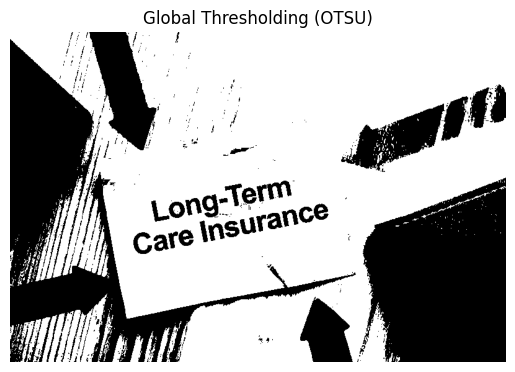

Extracted text (Global OTSU):
''


In [4]:
processed_global = preprocess_image_global(image_path)

plt.imshow(processed_global, cmap='gray')
plt.axis('off')
plt.title('Global Thresholding (OTSU)')
plt.show()

text_global = pytesseract.image_to_string(processed_global)
print("Extracted text (Global OTSU):")
print(repr(text_global))

Adaptive Thresholding

In [6]:
def preprocess_image_adaptive(image_path):
    """Convert image to black/white using adaptive (local) thresholding."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    adaptive = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=25,
        C=15
    )
    return adaptive

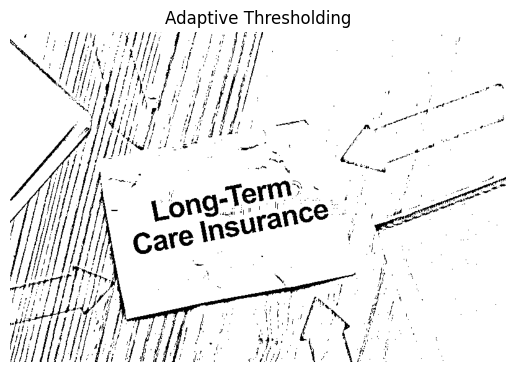

Extracted text (Adaptive Thresholding):
''


In [7]:
processed_adaptive = preprocess_image_adaptive(image_path)

plt.imshow(processed_adaptive, cmap='gray')
plt.axis('off')
plt.title('Adaptive Thresholding')
plt.show()

text_adaptive = pytesseract.image_to_string(processed_adaptive)
print("Extracted text (Adaptive Thresholding):")
print(repr(text_adaptive))